In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [3]:
df = pd.read_csv('survey_results_public.csv', low_memory=False)

schema_df = pd.read_csv('survey_results_schema.csv')

pd.set_option('display.max_columns', 85)
pd.set_option('display.max_rows', 85)

df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,...,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,...,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi...",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,5.0,7.0,14.0,NaN,14.0,1.0,13.0,10.0,9.0,3.0,4.0,2.0,5.0,15.0,NaN,Retail and Consumer Services,10.0,...,11.0,15.0,NaN,"Yes, somewhat",About half of the time,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning new concepts or technologies,Learning about a codebase;Project planning;Com...,Writing code;Documenting code;Debugging or fix...,NaN,NaN,"AI solutions that are almost right, but not qu...",No,"No, and I don't plan to",Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn ...,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [4]:
# Завдання 1/1. Підрахунок загальної кількості респондентів

total_respondents = df.shape[0]

print(f"Загальна кількість респондентів: {total_respondents}")

Загальна кількість респондентів: 49191


In [5]:
# Завдання 1/2. Підрахунок загальної кількості респондентів

total_respondents = len(df)

print(f"Загальна кількість респондентів: {total_respondents}")

Загальна кількість респондентів: 49191


In [6]:
# Завдання 2. Аналіз повноти відповідей респондентів

# Список унікальних імен 
schema_questions = set(schema_df['qname'])

# Список колонок
data_columns = set(df.columns)

# Інтерсекція даних та питань
questions_to_check = list(schema_questions.intersection(data_columns))

# Фільтрація порожніх значень
complete_responses_df = df[questions_to_check].dropna()

# Кількість респондентів
full_response_count = len(complete_responses_df)

print(f"Кількість питань для перевірки: {len(questions_to_check)}")
print(f"Кількість респондентів, які відповіли на ВСІ запитання: {full_response_count}")

Кількість питань для перевірки: 126
Кількість респондентів, які відповіли на ВСІ запитання: 0


In [7]:
# Завдання 3. Статистичний аналіз досвіду респондентів 

# 1. Розрахунок середнього значення 
mean_work_exp = df['WorkExp'].mean()

# 2. Розрахунок медіани 
median_work_exp = df['WorkExp'].median()

# 3. Розрахунок моди 
mode_work_exp = df['WorkExp'].mode()[0]

# Виведення результатів у зручному форматі
print("Статистика досвіду роботи респондентів (роки):")
print(f"-------------------------------------------")
print(f"Середнє значення (Mean): {mean_work_exp:.2f}")
print(f"Медіана (Median):        {median_work_exp}")
print(f"Мода (Mode):           {mode_work_exp}")

Статистика досвіду роботи респондентів (роки):
-------------------------------------------
Середнє значення (Mean): 13.37
Медіана (Median):        10.0
Мода (Mode):           10.0


In [8]:
# Завдання 3/2. Статистичний аналіз досвіду респондентів 
# 1. Кількість порожніх значень 
missing_count = df['WorkExp'].isna().sum()

# 2. Загальна кількість рядків 
total_count = len(df)

# 3. Відсоток пропусків
missing_percentage = (missing_count / total_count) * 100

print(f"Аналіз пропусків у колонці 'WorkExp':")
print(f"------------------------------------")
print(f"Кількість порожніх комірок: {missing_count}")
print(f"Загальна кількість записів: {total_count}")
print(f"Відсоток пропусків:         {missing_percentage:.2f}%")

Аналіз пропусків у колонці 'WorkExp':
------------------------------------
Кількість порожніх комірок: 6298
Загальна кількість записів: 49191
Відсоток пропусків:         12.80%


In [9]:
# Завдання 3/3. Статистичний аналіз досвіду респондентів
# Оскільки відсоток пропусків складає 12.8% вважаю доцільним заповнити їх медіаною
median_value = df['WorkExp'].median()
work_exp_median_filled = df['WorkExp'].fillna(median_value)

# 2. Нове середнє після заповнення медіаною
new_mean = work_exp_median_filled.mean()

print(f"Оригінальне середнє: {mean_work_exp:.2f}")
print(f"Середнє після заповнення медіаною ({median_value}): {new_mean:.2f}")

Оригінальне середнє: 13.37
Середнє після заповнення медіаною (10.0): 12.94


In [10]:
# Завдання 4. Аналіз віддаленої роботи

# 1. Визначення всіх унікальних варіантів в RemoteWork

print("Варіанти форматів роботи:")
print(df['RemoteWork'].unique())

# 2. Кількість респондентів, що працюють віддалено
remote_only_count = len(df[df['RemoteWork'] == 'Remote'])

print(f"------------------------------------")
print(f"Кількість респондентів у категорії 'Remote': {remote_only_count}")

Варіанти форматів роботи:
['Remote' 'Hybrid (some in-person, leans heavy to flexibility)' nan
 'In-person' 'Hybrid (some remote, leans heavy to in-person)'
 'Your choice (very flexible, you can come in when you want or just as needed)']
------------------------------------
Кількість респондентів у категорії 'Remote': 10931


Розподіл форматів роботи:
RemoteWork
NaN                                                                             15411
Remote                                                                          10931
Hybrid (some remote, leans heavy to in-person)                                   6732
In-person                                                                        6042
Hybrid (some in-person, leans heavy to flexibility)                              5831
Your choice (very flexible, you can come in when you want or just as needed)     4244
Name: count, dtype: int64


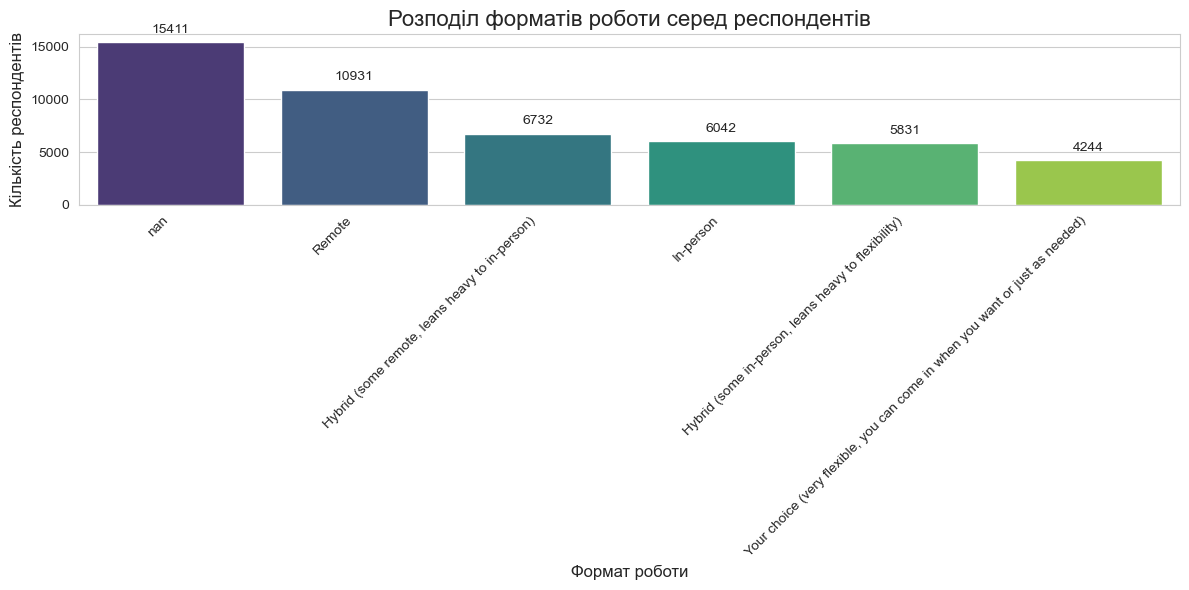

In [11]:
# Завдання 4/2. Аналіз віддаленої роботи
# Всі формати роботи респондентів
work_format_counts = df['RemoteWork'].value_counts(dropna=False)
print("Розподіл форматів роботи:")
print(work_format_counts)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x=work_format_counts.index.astype(str), 
    y=work_format_counts.values, 
    hue=work_format_counts.index.astype(str), 
    palette='viridis', 
    legend=False
)

plt.title('Розподіл форматів роботи серед респондентів', fontsize=16)
plt.xlabel('Формат роботи', fontsize=12)
plt.ylabel('Кількість респондентів', fontsize=12)

plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [13]:
# Завдання 5/0. Визначення популярності Python

# 0. Шукаємо колонку
search_word = 'Lang'

matching_columns = [(i, col) for i, col in enumerate(df.columns) if search_word in col]

print(f"{'Індекс':<7} | {'Назва колонки'}")
print("-" * 30)
for index, name in matching_columns:
    print(f"{index:<7} | {name}")

Індекс  | Назва колонки
------------------------------
64      | LanguageChoice
65      | LanguageHaveWorkedWith
66      | LanguageWantToWorkWith
67      | LanguageAdmired
68      | LanguagesHaveEntry
69      | LanguagesWantEntry


In [14]:
# Завдання 5. Визначення популярності Python

lang_column = 'LanguageHaveWorkedWith'

languages_data = df[lang_column].dropna()

#  Шукаємо слово 'Python' 
python_users_mask = languages_data.str.contains('Python', case=False, na=False)

#  Кількість користувачів Python
python_users_count = python_users_mask.sum()

#  Відсоток популярності Python
python_percentage = (python_users_count / len(languages_data)) * 100

print(f"Кількість респондентів, що використовують Python: {python_users_count}")
print(f"Загальна кількість тих, хто вказав мови: {len(languages_data)}")
print(f"Відсоток популярності Python: {python_percentage:.1f}%")

Кількість респондентів, що використовують Python: 18466
Загальна кількість тих, хто вказав мови: 31671
Відсоток популярності Python: 58.3%


ТОП-5 найпопулярніших мов (абсолютні числа):
LanguageHaveWorkedWith
JavaScript                 21005
HTML/CSS                   19698
SQL                        18633
Python                     18410
Bash/Shell (all shells)    15503
Name: count, dtype: int64


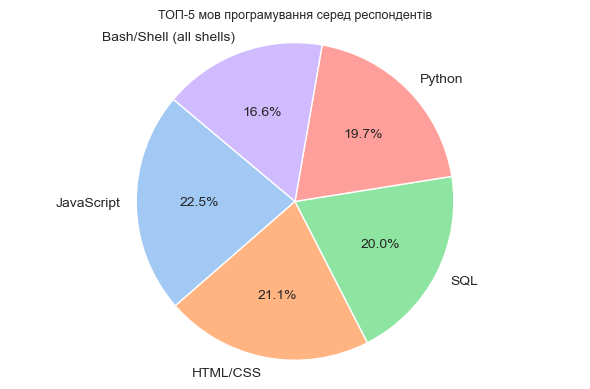

In [15]:
# Завдання 5/2. Визначення популярності Python

lang_column = 'LanguageHaveWorkedWith'
languages_data = df[lang_column].dropna()

all_languages_series = languages_data.str.split(';').explode()

top5_languages = all_languages_series.value_counts().head(5)

print("ТОП-5 найпопулярніших мов (абсолютні числа):")
print(top5_languages)

#  Графік
plt.figure(figsize=(6, 4))

colors = sns.color_palette('pastel')[0:5]

plt.pie(top5_languages.values, 
        labels=top5_languages.index, 
        colors=colors, 
        autopct='%1.1f%%', 
        startangle=140, 
        wedgeprops={'edgecolor': 'white'}) 


plt.title('ТОП-5 мов програмування серед респондентів', fontsize=9)
plt.axis('equal') 

plt.tight_layout()
plt.show()

In [17]:
# 0. Шукаємо колонку
search_word = 'Learn'

matching_columns = [(i, col) for i, col in enumerate(df.columns) if search_word in col]

print(f"{'Індекс':<7} | {'Назва колонки'}")
print("-" * 30)
for index, name in matching_columns:
    print(f"{index:<7} | {name}")

Індекс  | Назва колонки
------------------------------
7       | LearnCodeChoose
8       | LearnCode
9       | LearnCodeAI
10      | AILearnHow


In [18]:
# Завдання 6. Аналіз шляхів навчання (Онлайн-курси)

learn_column = 'LearnCode'

learn_data = df[learn_column].dropna()

unique_learning_methods = df['LearnCode'].str.split(';').explode().value_counts()

print("Всі доступні варіанти навчання у датасеті:")
print(unique_learning_methods)


online_learners_mask = learn_data.str.contains('Online Courses', case=False, na=False)

online_learners_count = online_learners_mask.sum()

print("-" * 30)
print(f"Кількість респондентів, які навчалися через онлайн-курси: {online_learners_count}")

Всі доступні варіанти навчання у датасеті:
LearnCode
Technical documentation (is generated for/by the tool or system)          22739
Other online resources (e.g. standard search, forum, online community)    19701
Stack Overflow or Stack Exchange                                          17245
Videos (not associated with specific online course or certification)      16771
AI CodeGen tools or AI-enabled apps                                       14753
Blogs or podcasts                                                         11688
Online Courses or Certification (includes all media types)                10973
Books / Physical media                                                    10187
Colleague or on-the-job training                                           8596
School (i.e., University, College, etc)                                    5561
Games or coding challenges                                                 4046
Coding Bootcamp                                                    

In [19]:
# Завдання 7. Географічний аналіз компенсації Python-розробників

needed_columns = ['Country', 'ConvertedCompYearly', 'LanguageHaveWorkedWith']

python_devs = df.loc[
    df['LanguageHaveWorkedWith'].str.contains('Python',case=False, na=False), 
    needed_columns
].copy()

python_devs = python_devs.dropna(subset=['ConvertedCompYearly'])


salary_stats = python_devs.groupby('Country')['ConvertedCompYearly'].agg(['mean', 'median'])

salary_stats.columns = ['Average Salary', 'Median Salary']
salary_stats = salary_stats.sort_values(by='Median Salary', ascending=False)

salary_stats = salary_stats.round(0).astype(int)

display(salary_stats.head(10))

,Average Salary,Median Salary
Country,,
Oman,390135,390135
Andorra,226104,226104
United States of America,173299,150000
Israel,135828,142594
Switzerland,156457,142592
Nomadic,120132,139218
Ireland,120524,116015
Luxembourg,116015,109054
Kyrgyzstan,106008,106008


,Average Salary,Median Salary,Devs Count
Country,,,
United States of America,173298.59,150000.0,3126
Israel,135828.37,142594.0,104
Switzerland,156456.60,142592.0,240
Ireland,120523.92,116015.0,74
Denmark,115672.42,98289.0,120
Australia,118091.41,97514.0,307
United Kingdom of Great Britain and Northern Ireland,117662.36,94958.5,750
Singapore,147515.12,91391.0,41
Norway,104690.12,89439.0,88


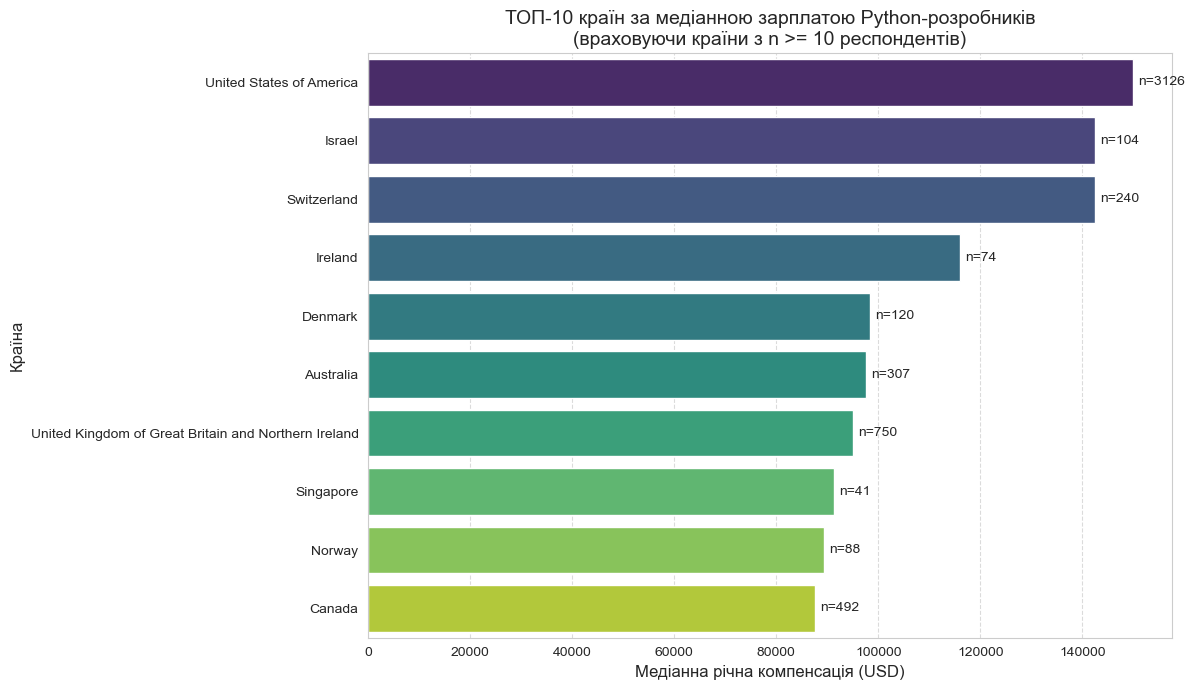

In [20]:
# Завдання 7/2. Географічний аналіз компенсації Python-розробників

salary_stats = python_devs.groupby('Country')['ConvertedCompYearly'].agg(['mean', 'median', 'count'])

salary_stats.columns = ['Average Salary', 'Median Salary', 'Devs Count']

salary_stats = salary_stats[salary_stats['Devs Count'] >= 10]

top_10_countries = salary_stats.sort_values(by='Median Salary', ascending=False).head(10).round(2)

display(top_10_countries)

plt.figure(figsize=(12, 7))

# графік 
ax = sns.barplot(
    x=top_10_countries['Median Salary'], 
    y=top_10_countries.index, 
    hue=top_10_countries.index, 
    palette='viridis',
    legend=False               
)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    count = top_10_countries['Devs Count'].iloc[i]
    ax.text(
        width + 1000,       
        p.get_y() + p.get_height()/2, 
        f'n={int(count)}',  
        va='center'
    )

plt.title('ТОП-10 країн за медіанною зарплатою Python-розробників\n(враховуючи країни з n >= 10 респондентів)', fontsize=14)
plt.xlabel('Медіанна річна компенсація (USD)', fontsize=12)
plt.ylabel('Країна', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [21]:
# Завдання 8. Аналіз освіти найбільш оплачуваних спеціалістів

needed_columns = ['ConvertedCompYearly', 'EdLevel']

top_paid_df = df[needed_columns].dropna(subset=['ConvertedCompYearly']).copy()

top_paid_df['ConvertedCompYearly'] = top_paid_df['ConvertedCompYearly'].round(0).astype(int)

final_top_5 = top_paid_df.sort_values(by='ConvertedCompYearly', ascending=False).head(5).reset_index(drop=True)
final_top_5.index = final_top_5.index + 1

print("Освіта та річна зарплата 5 найбільш оплачуваних спеціалістів:")
display(final_top_5)

Освіта та річна зарплата 5 найбільш оплачуваних спеціалістів:


,ConvertedCompYearly,EdLevel
1,50000000,"Associate degree (A.A., A.S., etc.)"
2,33552715,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"
3,18387548,"Associate degree (A.A., A.S., etc.)"
4,15430267,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
5,13921760,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"


In [22]:
# Завдання 9. Аналіз популярності Python по віковим категоріям 

needed_columns = ['Age', 'LanguageHaveWorkedWith']

age_analysis_df = df[needed_columns].copy()

age_analysis_df = age_analysis_df.dropna(subset=['Age', 'LanguageHaveWorkedWith'])

age_analysis_df['Uses_Python'] = age_analysis_df['LanguageHaveWorkedWith'].str.contains('Python', case=False, na=False)

python_by_age = age_analysis_df.groupby('Age')['Uses_Python'].mean() * 100

python_by_age = python_by_age.reset_index()
python_by_age.columns = ['Age Category', 'Python Popularity (%)']
python_by_age = python_by_age.round(2).sort_values(by='Python Popularity (%)', ascending=False)

final_age_table = python_by_age.copy()

final_age_table['Python Popularity (%)'] = final_age_table['Python Popularity (%)'].round(1)

mask = final_age_table['Age Category'] == 'Prefer not to say'

final_age_table = pd.concat([final_age_table[~mask], final_age_table[mask]])

final_age_table = final_age_table.reset_index(drop=True)
final_age_table.index = final_age_table.index + 1

display(final_age_table)

,Age Category,Python Popularity (%)
1,18-24 years old,71.9
2,25-34 years old,59.5
3,35-44 years old,54.2
4,45-54 years old,54.1
5,55-64 years old,49.2
6,65 years or older,44.0
7,Prefer not to say,67.0


In [23]:
# Завдання 10. Аналіз індустрій серед високооплачуваних віддалених працівників

needed_columns = ['ConvertedCompYearly', 'RemoteWork', 'Industry']


remote_high_earners = df[needed_columns].copy()

remote_high_earners = remote_high_earners.dropna(subset=['ConvertedCompYearly', 'RemoteWork', 'Industry'])

# Знаходимо поріг 75-го перцентиля
salary_threshold = remote_high_earners['ConvertedCompYearly'].quantile(0.75)

# фільтр: хто заробляє більше порогу та працює віддалено
high_remote_mask = (remote_high_earners['ConvertedCompYearly'] > salary_threshold) & \
                   (remote_high_earners['RemoteWork'] == 'Remote')

top_remote_devs = remote_high_earners[high_remote_mask]

# створення нової таблиці на основі булевого стовпчика
industry_stats = top_remote_devs['Industry'].value_counts().reset_index()

industry_stats.columns = ['Галузь (Industry)', 'Кількість фахівців']

industry_stats.index = industry_stats.index + 1


display(industry_stats.head(10))



,Галузь (Industry),Кількість фахівців
1,Software Development,1174
2,Fintech,188
3,Healthcare,186
4,Other:,176
5,"Internet, Telecomm or Information Services",137
6,Banking/Financial Services,87
7,Government,78
8,Media & Advertising Services,75
9,Retail and Consumer Services,65
10,"Transportation, or Supply Chain",63
